In [1]:
import pandas as pd
names=['label','name','sequence']
df= pd.read_csv('promoters.data',names=names)
df.head()
df['sequence']=df['sequence'].apply(lambda x: x.replace('\t',''))
df.head()
#kmer function 
def get_kmers(sequence,k=3):
    return [sequence[i:i+k] for i in range(len(sequence)-k+1)]
get_kmers("abcg",2)    
df['kmers']=df['sequence'].apply(lambda x : get_kmers(x, 3))
df['kmers2']=df['sequence'].apply(lambda x : get_kmers(x, 2))

df['kmers4']=df['sequence'].apply(lambda x : get_kmers(x, 4))
df['kmers6']=df['sequence'].apply(lambda x : get_kmers(x, 6))
df['kmers'].head()
df['count']=df['kmers'].apply(lambda x: len(x))
df['count'].head()
df.head()


,label,name,sequence,kmers,kmers2,kmers4,kmers6,count
0,+,S10,tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgc...,"[tac, act, cta, tag, agc, gca, caa, aat, ata, ...","[ta, ac, ct, ta, ag, gc, ca, aa, at, ta, ac, c...","[tact, acta, ctag, tagc, agca, gcaa, caat, aat...","[tactag, actagc, ctagca, tagcaa, agcaat, gcaat...",55
1,+,AMPC,tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaa...,"[tgc, gct, cta, tat, atc, tcc, cct, ctg, tga, ...","[tg, gc, ct, ta, at, tc, cc, ct, tg, ga, ac, c...","[tgct, gcta, ctat, tatc, atcc, tcct, cctg, ctg...","[tgctat, gctatc, ctatcc, tatcct, atcctg, tcctg...",55
2,+,AROH,gtactagagaactagtgcattagcttatttttttgttatcatgcta...,"[gta, tac, act, cta, tag, aga, gag, aga, gaa, ...","[gt, ta, ac, ct, ta, ag, ga, ag, ga, aa, ac, c...","[gtac, tact, acta, ctag, taga, agag, gaga, aga...","[gtacta, tactag, actaga, ctagag, tagaga, agaga...",55
3,+,DEOP2,aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaata...,"[aat, att, ttg, tgt, gtg, tga, gat, atg, tgt, ...","[aa, at, tt, tg, gt, tg, ga, at, tg, gt, tg, g...","[aatt, attg, ttgt, tgtg, gtga, tgat, gatg, atg...","[aattgt, attgtg, ttgtga, tgtgat, gtgatg, tgatg...",55
4,+,LEU1_TRNA,tcgataattaactattgacgaaaagctgaaaaccactagaatgcgc...,"[tcg, cga, gat, ata, taa, aat, att, tta, taa, ...","[tc, cg, ga, at, ta, aa, at, tt, ta, aa, ac, c...","[tcga, cgat, gata, ataa, taat, aatt, atta, tta...","[tcgata, cgataa, gataat, ataatt, taatta, aatta...",55


In [2]:
import  itertools
def get_all_kmers(k):
    return [''.join(p) for p in itertools.product('atgc',repeat=k)]


In [16]:
from collections import Counter
def count_of_kmers_each_sequence(sequence,k):
    kmer= get_kmers(sequence,k)
    count=Counter(kmer)
    return [count[kmers] for kmers in get_all_kmers(k)]
X3= df['sequence'].apply(lambda x:  count_of_kmers_each_sequence(x,3))
X3.head()
X3=pd.DataFrame(X3.tolist(),columns=get_all_kmers(3))
X3.head()
#for kmer length 2
X2= df['sequence'].apply(lambda x:  count_of_kmers_each_sequence(x,2))
X2.head()
X2=pd.DataFrame(X2.tolist(),columns=get_all_kmers(2))
X2.head()
X4= df['sequence'].apply(lambda x:  count_of_kmers_each_sequence(x,4))
X4.head()
X4=pd.DataFrame(X4.tolist(),columns=get_all_kmers(4))
X4.head()
X4.value_counts()

#X6= df['sequence'].apply(lambda x:  count_of_kmers_each_sequence(x,6))
#X6.head()
#X6=pd.DataFrame(X6.tolist(),columns=get_all_kmers(6))
#X6.head()
#X6.value_counts()

aaaa  aaat  aaag  aaac  aata  aatt  aatg  aatc  aaga  aagt  aagg  aagc  aaca  aact  aacg  aacc  ataa  atat  atag  atac  atta  attt  attg  attc  atga  atgt  atgg  atgc  atca  atct  atcg  atcc  agaa  agat  agag  agac  agta  agtt  agtg  agtc  agga  aggt  aggg  aggc  agca  agct  agcg  agcc  acaa  acat  acag  acac  acta  actt  actg  actc  acga  acgt  acgg  acgc  acca  acct  accg  accc  taaa  taat  taag  taac  tata  tatt  tatg  tatc  taga  tagt  tagg  tagc  taca  tact  tacg  tacc  ttaa  ttat  ttag  ttac  ttta  tttt  tttg  tttc  ttga  ttgt  ttgg  ttgc  ttca  ttct  ttcg  ttcc  tgaa  tgat  tgag  tgac  tgta  tgtt  tgtg  tgtc  tgga  tggt  tggg  tggc  tgca  tgct  tgcg  tgcc  tcaa  tcat  tcag  tcac  tcta  tctt  tctg  tctc  tcga  tcgt  tcgg  tcgc  tcca  tcct  tccg  tccc  gaaa  gaat  gaag  gaac  gata  gatt  gatg  gatc  gaga  gagt  gagg  gagc  gaca  gact  gacg  gacc  gtaa  gtat  gtag  gtac  gtta  gttt  gttg  gttc  gtga  gtgt  gtgg  gtgc  gtca  gtct  gtcg  gtcc  ggaa  ggat  ggag  ggac  ggta  ggtt  ggtg

In [4]:
Y=df['label'].map({'+':1,'-':0})
Y.value_counts()

label
1    53
0    53
Name: count, dtype: int64

In [17]:
import sklearn
print(sklearn.__version__)
from sklearn.model_selection import train_test_split
#spliiting the data bc 20% of the data will be used for training and rest for testing
X3_train,X3_test,Y_train,Y_test = train_test_split(
    X3,Y,test_size=0.2,random_state=42)
#for kmer length 2
X2_train,X2_test,Y_train,Y_test = train_test_split(
    X2,Y,test_size=0.2,random_state=42)

X4_train,X4_test,Y_train,Y_test = train_test_split(
    X4,Y,test_size=0.2,random_state=42)

#X6_train,X6_test,Y_train,Y_test = train_test_split(
    #X6,Y,train_size=0.2,random_state=42)

1.5.1


In [18]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, Y_train)
y_pred_lr = model_lr.predict(X3_test)

#for kmer length 2
model_lr2 = LogisticRegression(max_iter=1000)
model_lr2.fit(X2_train, Y_train)
y2_pred_lr = model_lr2.predict(X2_test)

#for kmer length 4
model_lr4 = LogisticRegression(max_iter=1000)
model_lr4.fit(X4_train, Y_train)
y4_pred_lr = model_lr4.predict(X4_test)


#for kmer length 6
#model_lr6 = LogisticRegression(max_iter=1000)
#model_lr6.fit(X6_train, Y_train)
#y6_pred_lr = model_lr6.predict(X6_test)

In [20]:
#2
from sklearn.metrics import accuracy_score, classification_report
test2_acc=accuracy_score(Y_test, y2_pred_lr)
train2_acc= accuracy_score(Y_train, model_lr2.predict(X2_train))
print('test2_acc',test2_acc, 'train2_acc',train2_acc)
#3

from sklearn.metrics import accuracy_score, classification_report
test3_acc=accuracy_score(Y_test, y_pred_lr)
train3_acc= accuracy_score(Y_train, model_lr.predict(X3_train))
print('test3_acc',test3_acc, 'train3_acc',train3_acc)# here train_acc>test_acc which is overfitting even when kmer length is small bc my dataset is really smallso model memorires instead of generalizing

#4
test4_acc=accuracy_score(Y_test, y4_pred_lr)
train4_acc= accuracy_score(Y_train, model_lr4.predict(X4_train))
print('test4_acc',test4_acc, 'train4_acc',train4_acc)

#6
#test6_acc=accuracy_score(Y_test, y6_pred_lr)
#train6_acc= accuracy_score(Y_train, model_lr6.predict(X6_train))
#print('test6_acc',test6_acc, 'train6_acc',train6_acc)

test2_acc 0.7272727272727273 train2_acc 0.8928571428571429
test3_acc 0.9090909090909091 train3_acc 1.0
test4_acc 0.9545454545454546 train4_acc 1.0


In [9]:
print(classification_report(Y_test, y_pred_lr))
print(classification_report(Y_test, y2_pred_lr))
from sklearn.metrics import confusion_matrix
cm1= confusion_matrix(Y_test, y_pred_lr)
cm1_df=pd.DataFrame(cm1,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print(cm1_df)

cm2= confusion_matrix(Y_test, y2_pred_lr)
cm2_df=pd.DataFrame(cm2,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print(cm2_df)


              precision    recall  f1-score   support

           0       1.00      0.82      0.90        11
           1       0.85      1.00      0.92        11

    accuracy                           0.91        22
   macro avg       0.92      0.91      0.91        22
weighted avg       0.92      0.91      0.91        22

              precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.73      0.73      0.73        11

    accuracy                           0.73        22
   macro avg       0.73      0.73      0.73        22
weighted avg       0.73      0.73      0.73        22

          predicted -  predicted +
actual -            9            2
actual +            0           11
          predicted -  predicted +
actual -            8            3
actual +            3            8


In [21]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X3_train, Y_train)
y_pred_rf = model_rf.predict(X_test)
print("RF Accuracy:", accuracy_score(Y_test, y_pred_rf))

RF Accuracy: 0.9090909090909091


In [22]:
print(classification_report(Y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      0.82      0.90        11
           1       0.85      1.00      0.92        11

    accuracy                           0.91        22
   macro avg       0.92      0.91      0.91        22
weighted avg       0.92      0.91      0.91        22



In [11]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test, y_pred_rf)
cm_df=pd.DataFrame(cm,
                   index=['actual -','actual+'],
                   columns=['predicted -','predicted +'])
print(cm_df)# fn is not so low in my openion

          predicted -  predicted +
actual -            9            2
actual+             1           10


In [13]:
# here recall ( out of 100 promoters , model can predict 91 promoters) 9% fn
#precision( for 1 , called false positive , so 24% of the time model is wrong
#The model prioritizes recall over precision for promoter detection, reducing the likelihood of missing true promoters at the expense of a moderate increase in false positives

In [23]:
from sklearn.metrics import roc_curve, auc 
import matplotlib.pyplot as plt
y_prob= model_lr.predict_proba(X_test)[:,1]# gives the probability of a sequence beign promoter bc we added 1 here 
fpr, tpr, _ = roc_curve(Y_test, y_prob)# - is the part of thresholds , so if i need it i can write it , but for plotting i might not use thsis
roc_auc = auc(fpr, tpr)

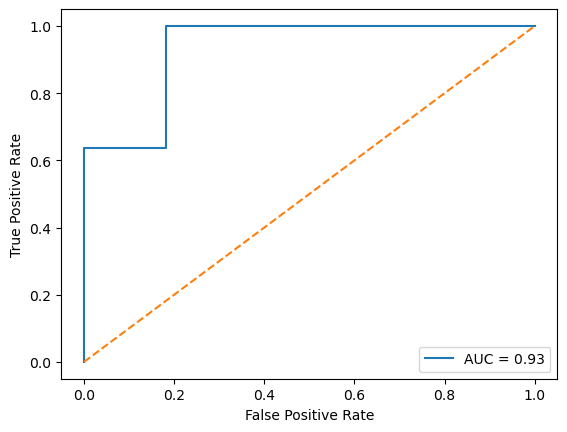

In [24]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.legend() 
plt.show()# auc is 0.87 means if i choose one 0 and 1 randomely the model will assign 1 to have higher rank which is probability here 

# cross validation

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
import numpy as np
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scorers = {
    "accuracy": "accuracy",
    "recall_promoter": make_scorer(recall_score, pos_label=1),
    "recall_nonpromoter": make_scorer(recall_score, pos_label=0)
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

feature_sets = {2: X2, 3: X3, 4: X4}

results = []

for k, X in feature_sets.items():
    for model_name, model in models.items():
        cv_results = cross_validate(model, X, Y, cv=cv, scoring=scorers)
        results.append({
            "Model": model_name,
            "k": k,
            "Mean Accuracy": round(np.mean(cv_results["test_accuracy"]), 4),
            "Std Dev": round(np.std(cv_results["test_accuracy"]), 4),
            "Mean Recall (Promoter)": round(np.mean(cv_results["test_recall_promoter"]), 4),
            "Mean Recall (Non-Promoter)": round(np.mean(cv_results["test_recall_nonpromoter"]), 4)
        })
        print(f"✓ Done: {model_name} | k={k}")

results_df = pd.DataFrame(results).sort_values(["Model", "k"]).reset_index(drop=True)
results_df

✓ Done: Logistic Regression | k=2
✓ Done: Random Forest | k=2
✓ Done: Logistic Regression | k=3
✓ Done: Random Forest | k=3
✓ Done: Logistic Regression | k=4
✓ Done: Random Forest | k=4


,Model,k,Mean Accuracy,Std Dev,Mean Recall (Promoter),Mean Recall (Non-Promoter)
0,Logistic Regression,2,0.8494,0.0812,0.8691,0.8327
1,Logistic Regression,3,0.8680,0.0761,0.8109,0.9273
2,Logistic Regression,4,0.9437,0.0347,0.9055,0.9818
3,Random Forest,2,0.8684,0.0808,0.8673,0.8727
4,Random Forest,3,0.9056,0.0522,0.9055,0.9091
5,Random Forest,4,0.8961,0.0359,0.8873,0.9055


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble  import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer

scorers={
    'accuracy':'accuracy',
    'recall_promoter': make_scorer(recall_score, pos_label=1),
    'recall_nonpromoter': make_scorer(recall_score, pos_label=0)
}
cv= StratifiedKFold( n_splits=5,shuffle=True, random_state=42)
k_value={2:X2,3:X3,4:X4}
model_d={
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}
result=[]
for k,X in k_value.items():
    for model_name, model in  model_d.items():
        cv_result=cross_validate(model, X,Y ,cv=cv, scoring= scorers)
        result.append({
            'model':model_name,
            'k':k,
            'mean_accuracy':round(np.mean(cv_result['test_accuracy']),4),
            'mean_std':round(np.mean(cv_result['test_accuracy']),4),
            'mean_recall_promote':round(np.mean(cv_result['test_recall_promoter']),4),
                'mean_recall_nonpromote':round(np.mean(cv_result['test_recall_nonpromoter']),4)})
        print("Done" ,model_name ,'for k:',k)
result_pd=pd.DataFrame(result).sort_values(['model','k']). reset_index(drop=True)  
result_pd

Done Logistic Regression for k: 2
Done Random Forest for k: 2
Done Logistic Regression for k: 3
Done Random Forest for k: 3
Done Logistic Regression for k: 4
Done Random Forest for k: 4


,model,k,mean_accuracy,mean_std,mean_recall_promote,mean_recall_nonpromote
0,Logistic Regression,2,0.8494,0.8494,0.8691,0.8327
1,Logistic Regression,3,0.8680,0.8680,0.8109,0.9273
2,Logistic Regression,4,0.9437,0.9437,0.9055,0.9818
3,Random Forest,2,0.8684,0.8684,0.8673,0.8727
4,Random Forest,3,0.9056,0.9056,0.9055,0.9091
5,Random Forest,4,0.8961,0.8961,0.8873,0.9055



# plot of cross validation


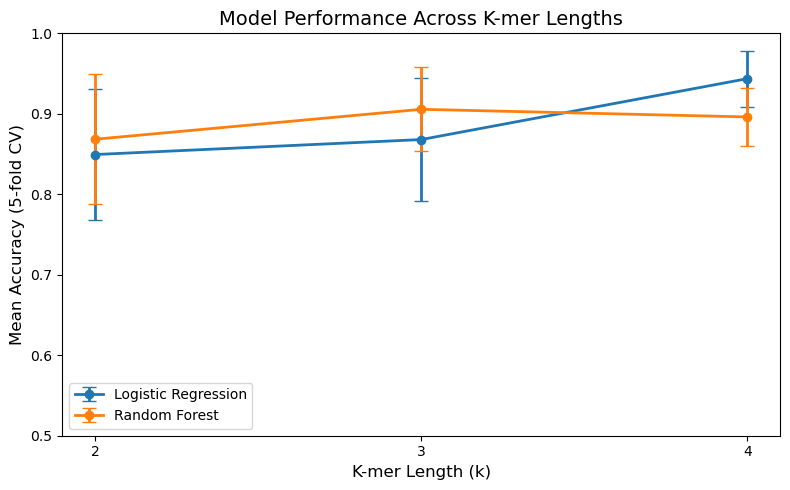

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for model_name in ["Logistic Regression", "Random Forest"]:
    subset = results_df[results_df["Model"] == model_name]
    ax.errorbar(
        subset["k"], subset["Mean Accuracy"], yerr=subset["Std Dev"],
        marker='o', label=model_name, capsize=5, linewidth=2
    )

ax.set_xlabel("K-mer Length (k)", fontsize=12)
ax.set_ylabel("Mean Accuracy (5-fold CV)", fontsize=12)
ax.set_title("Model Performance Across K-mer Lengths", fontsize=14)
ax.legend()
ax.set_xticks([2, 3, 4])
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("kmer_cv_comparison.png", dpi=150)
plt.show()